Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Class weight: {0: 1.0, 1: np.float64(8.11)}
Train: (11303, 50, 6) | Val: (2417, 50, 6) | Test: (2317, 50, 6)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 8)          │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 8)          │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345 (1.35 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 16 (64.00 B)

Epoch 1/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8400 - loss: 0.5256 - val_accuracy: 0.9293 - val_loss: 0.1848
Epoch 2/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9041 - loss: 0.3201 - val_accuracy: 0.9441 - val_loss: 0.1357
Epoch 3/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9147 - loss: 0.2846 - val_accuracy: 0.9512 - val_loss: 0.1216
Epoch 4/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9242 - loss: 0.2555 - val_accuracy: 0.9619 - val_loss: 0.1058
Epoch 5/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9354 - loss: 0.2246 - val_accuracy: 0.9756 - val_loss: 0.0893
Epoch 6/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9444 - loss: 0.2009 - val_accuracy: 0.9806 - val_loss: 0.0734
Epoch 7/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9536 - loss: 0.1940 - val_accuracy: 0.9801 - val_loss: 0.0708
Epoch 8/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9562 - loss: 0.1820 - val_accuracy: 0.

<Figure size 600x500 with 0 Axes>

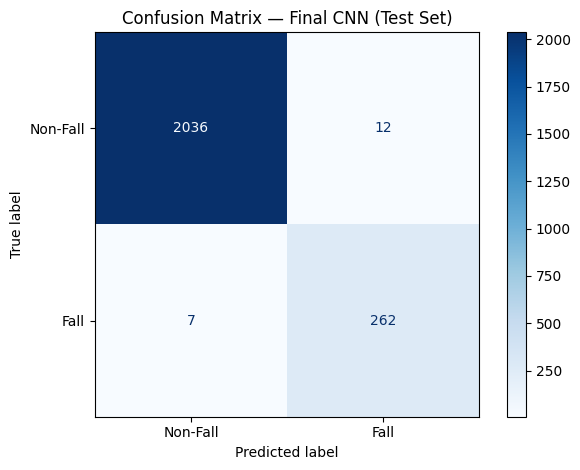

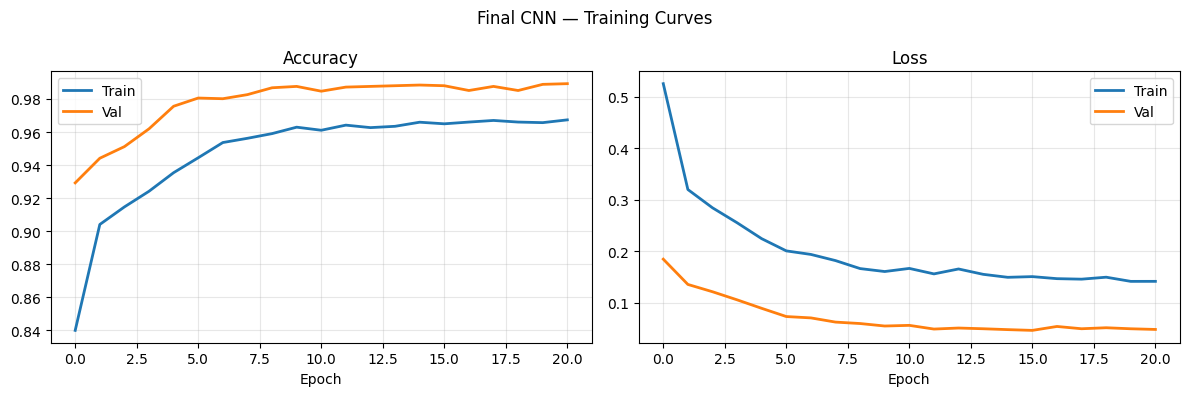

Saved artifact at '/tmp/tmph8vfmtxv'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138260315089488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138260315090832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138259886912528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138259886912912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138260315085456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138260315089680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138259886915024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138259886906960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138259886914448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138259886912336: TensorSpec(shape=(), dtype=tf.resource, name=None)

MODEL SIZE
Keras  : 4

In [3]:
# =========================
# FINAL OPTIMISED CNN
# conv_layers=1, filters=8, kernel=3, dense=16, dropout=0.3, batch=32, lr=0.001
# =========================

import os, tempfile, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from google.colab import drive

drive.mount('/content/drive')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

DATA_PATH  = "/content/drive/MyDrive/dataset_exp4_v4_final.npz"
SAVE_DIR   = "/content/drive/MyDrive/final_cnn_sisfall_v2"
os.makedirs(SAVE_DIR, exist_ok=True)

data = np.load(DATA_PATH, allow_pickle=True)
X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]

CLASS_WEIGHT = {0: 1.0, 1: round((y_train == 0).sum() / (y_train == 1).sum(), 2)}
print("Class weight:", CLASS_WEIGHT)
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


# =========================
# MODEL
# =========================
def build_final_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=X_train.shape[1:]),
        tf.keras.layers.Conv1D(8, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


# =========================
# HELPERS
# =========================
def model_size_kb(model):
    tmp = tempfile.mkdtemp()
    kpath = os.path.join(tmp, "m.keras")
    tpath = os.path.join(tmp, "m.tflite")
    model.save(kpath, overwrite=True)
    keras_kb = os.path.getsize(kpath) / 1024
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite = converter.convert()
    with open(tpath, "wb") as f: f.write(tflite)
    tflite_kb = os.path.getsize(tpath) / 1024
    return round(keras_kb, 2), round(tflite_kb, 2), tflite


def find_best_threshold(y_true, probs):
    best_th, best_f1 = 0.5, -1.0
    for th in np.arange(0.10, 0.91, 0.05):
        score = f1_score(y_true, (probs >= th).astype(int), zero_division=0)
        if score > best_f1:
            best_f1, best_th = score, th
    return float(best_th), round(best_f1, 4)


# =========================
# TRAIN
# =========================
tf.keras.backend.clear_session()
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

model = build_final_cnn()
model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=CLASS_WEIGHT,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)


# =========================
# THRESHOLD TUNING (val only)
# =========================
val_probs = model.predict(X_val, verbose=0).ravel()
best_threshold, val_f1 = find_best_threshold(y_val, val_probs)
print(f"\nBest threshold: {best_threshold:.2f}  |  Val F1: {val_f1:.4f}")


# =========================
# TEST EVALUATION
# =========================
test_probs = model.predict(X_test, verbose=0).ravel()
y_pred = (test_probs >= best_threshold).astype(int)

acc   = accuracy_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred, zero_division=0)
prec  = precision_score(y_test, y_pred, zero_division=0)
rec   = recall_score(y_test, y_pred, zero_division=0)
cm    = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Threshold      : {best_threshold:.2f}")
print(f"Val F1         : {val_f1:.4f}")
print(f"Test Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Test F1        : {f1:.4f}")
print(f"Test Precision : {prec:.4f}")
print(f"Test Recall    : {rec:.4f}")
print(f"\nConfusion Matrix:")
print(f"  TP={tp}  FN={fn}  (missed falls)")
print(f"  FP={fp}  TN={tn}  (false alarms)")

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred,
      target_names=["Non-Fall", "Fall"], digits=4, zero_division=0))


# =========================
# CONFUSION MATRIX PLOT
# =========================
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Non-Fall", "Fall"]).plot(
    cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Final CNN (Test Set)")
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()


# =========================
# TRAINING CURVES
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2)
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Final CNN — Training Curves')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()


# =========================
# SAVE MODEL + THRESHOLD
# =========================
keras_kb, tflite_kb, tflite_model = model_size_kb(model)

model.save(os.path.join(SAVE_DIR, "final_cnn_v2.keras"), overwrite=True)

with open(os.path.join(SAVE_DIR, "final_cnn_v2.tflite"), "wb") as f:
    f.write(tflite_model)

with open(os.path.join(SAVE_DIR, "best_threshold.txt"), "w") as f:
    f.write(str(best_threshold))

print("\n" + "="*50)
print("MODEL SIZE")
print("="*50)
print(f"Keras  : {keras_kb:.2f} KB")
print(f"TFLite : {tflite_kb:.2f} KB")
print(f"Saved to: {SAVE_DIR}")